# Training a MNIST Model with TensorFlow Dataset

## Data

In [1]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

2023-10-11 05:31:11.351848: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-11 05:31:11.596642: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-11 05:31:11.598138: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-11 05:31:12.624970: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    "mnist",
    split=["train", "test"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
ds_info

2023-10-11 05:31:14.344639: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-10-11 05:31:14.345200: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/home/yuncong/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",
)

In [3]:
for image, label in ds_train.take(1):
    print(image.shape, label)

(28, 28, 1) tf.Tensor(4, shape=(), dtype=int64)


2023-10-11 05:31:14.514721: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## Preprocessing

In [4]:
from typing import Tuple
import numpy as np


def convert_form(
    ds: tf.data.Dataset, ds_info: tfds.core.dataset_info.DatasetInfo
) -> Tuple[np.ndarray, np.ndarray]:
    df_ds = tfds.as_dataframe(ds=ds, ds_info=ds_info)
    x, y = df_ds["image"], df_ds["label"]
    x = np.stack(x.to_numpy(), axis=0)
    y = np.stack(y.to_numpy(), axis=0)

    return x, y


x_train, y_train = convert_form(ds=ds_train, ds_info=ds_info)
x_test, y_test = convert_form(ds=ds_test, ds_info=ds_info)
x_test.shape

(10000, 28, 28, 1)

In [5]:
import pandas as pd

x_train, x_test = x_train / 255.0, x_test / 255.0
pd.Series(x_test.ravel()).describe()

count    7.840000e+06
mean     1.325146e-01
std      3.104803e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64

In [6]:
import numpy as np

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [7]:
import numpy as np

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

## Train Model

In [8]:
%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

In [9]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10),
    ]
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[
        tf.keras.callbacks.TensorBoard(log_dir="./logs"),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ],
)

Epoch 1/20
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2531 - sparse_categorical_accuracy: 0.9270 - val_loss: 0.1360 - val_sparse_categorical_accuracy: 0.9592
Epoch 2/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1094 - sparse_categorical_accuracy: 0.9674 - val_loss: 0.1073 - val_sparse_categorical_accuracy: 0.9673
Epoch 3/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0757 - sparse_categorical_accuracy: 0.9768 - val_loss: 0.0962 - val_sparse_categorical_accuracy: 0.9703
Epoch 4/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0573 - sparse_categorical_accuracy: 0.9813 - val_loss: 0.0725 - val_sparse_categorical_accuracy: 0.9765
Epoch 5/20
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0447 - sparse_categorical_accuracy: 0.9862 - val_loss: 0.0765 - val_sparse_categorical_accuracy: 0.9753
Epoch 6/20
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0337 - spars

## Evaluation

In [10]:
model.evaluate(x=x_test, y=y_test)

313/313 [==============================] - 0s 898us/step - loss: 0.0696 - sparse_categorical_accuracy: 0.9802


[0.06960709393024445, 0.9801999926567078]

In [11]:
y_pred = np.argmax(model.predict(x_test), axis=1)
y_pred.shape

313/313 [==============================] - 0s 821us/step


(10000,)

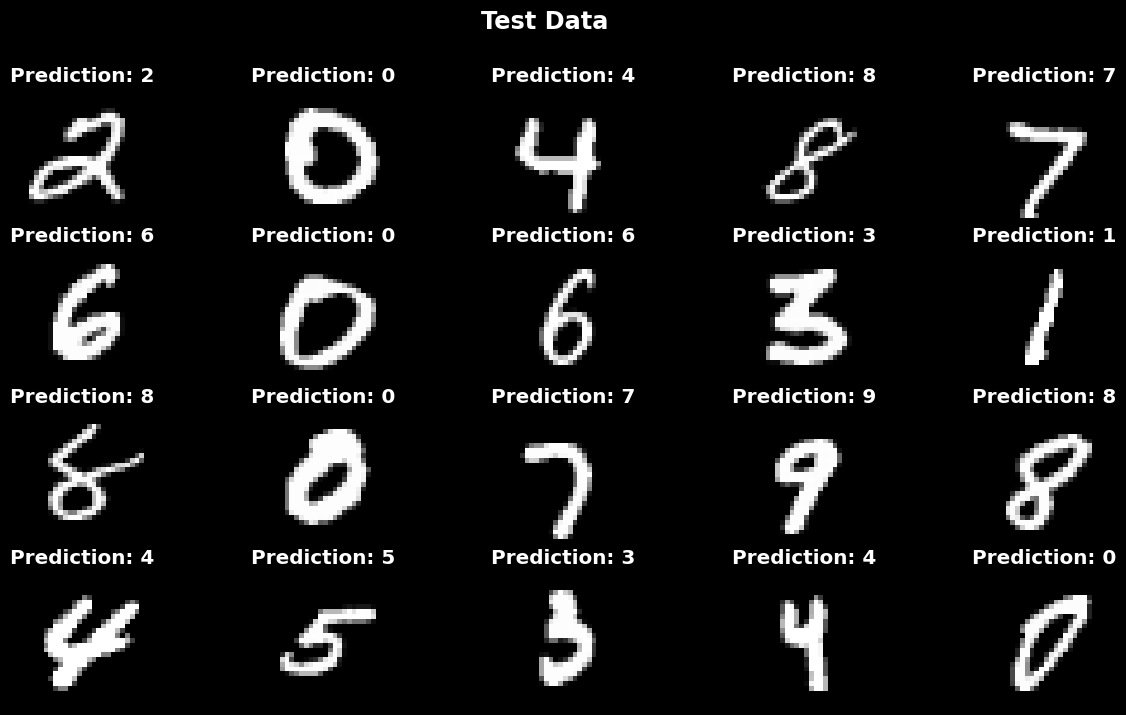

In [12]:
from data_science.util.print_images_in_subfigures import print_images_in_subfigures


print_images_in_subfigures(
    images=x_test[:20],
    labels=y_pred[:20],
    subtitle_prefix="Prediction",
    title="Test Data",
)